### Visualization: Matplotlib & Seaborn

Matplotlib is Python's primary library for creating static, animated, and interactive visualizations.

The library is built around two core components:

**Figure**: The top-level container that holds all plot elements. A figure can contain one or more axes.

**Axes**: The plotting area where data is displayed. Each axes object includes an x-axis and y-axis (plus z-axis for 3D plots) and provides methods for plotting data points. 


![Matplotlib Figure and Axes (Source: matplotlib.org)](figures/anatomy.png){width="60%"}

:::{.callout-note}
Documentation for these packages is available at https://matplotlib.org/stable/ and https://seaborn.pydata.org/api.html.
:::

We can import Matplotlib as follows

In [1]:
import matplotlib.pyplot as plt

Seaborn is built on top of Matplotlib and provides a high-level interface for drawing attractive and informative statistical graphics. We can import Seaborn as follows

In [2]:
import seaborn as sns

For some examples, we won't need seaborn, but we are importing it here because it has some built-in datasets that we can use for visualization. Let's load one of these datasets:

In [3]:
# Load the 'tips' dataset from seaborn
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


We have loaded a dataset that contains information about tips received by waitstaff in a restaurant, including total bill amount, tip amount, gender of the payer, whether they are a smoker, day of the week, time of day, and size of the party.

We have already seen how to create simple plots using Pandas. For example, we can create a scatter plot of total bill vs. tip using Pandas' built-in plotting capabilities (which uses Matplotlib under the hood)

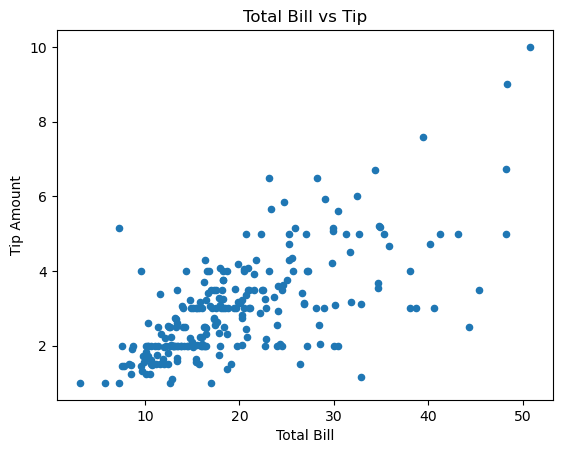

In [4]:
df.plot.scatter(x='total_bill', y='tip', title='Total Bill vs Tip', xlabel='Total Bill', ylabel='Tip Amount')
plt.show()

Oftentimes, this is enough for making a quick plot. We can use Matplotlib directly

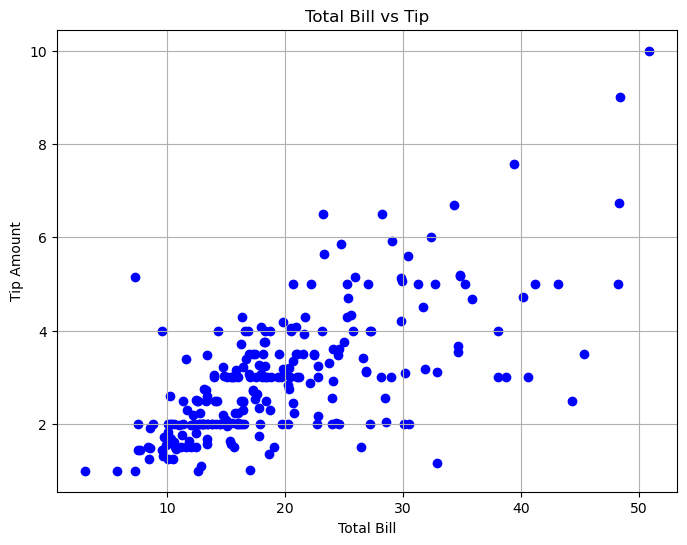

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(df['total_bill'], df['tip'], color='blue')
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip Amount')
plt.grid(True)
plt.show()

To save a figure to a file, use `plt.savefig('filename.png')`. You can specify different formats (e.g., `.pdf`, `.svg`, `.jpg`) and adjust the resolution with the `dpi` parameter (e.g., `plt.savefig('figure.png', dpi=300)`). In Jupyter notebooks, call `savefig()` before `plt.show()`, as `show()` may clear the figure.

Suppose we want to create a scatter plot that distinguishes between smokers and non-smokers using different colors. We can do this by creating two separate scatter plots and adding them to the same axes

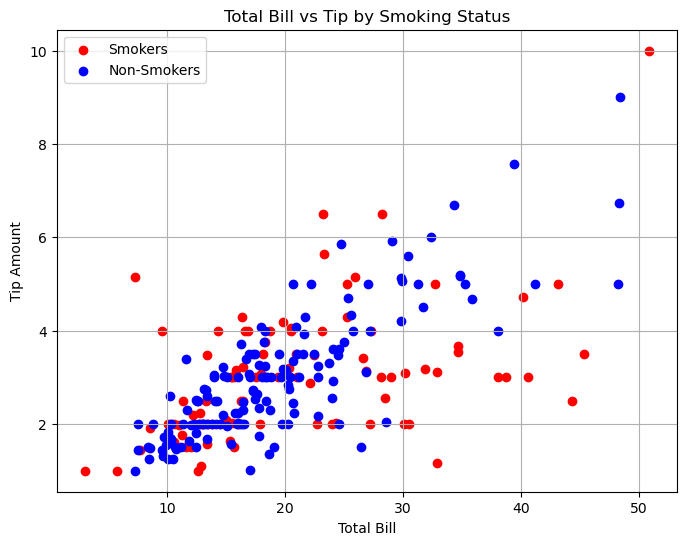

In [6]:
plt.figure(figsize=(8, 6))
smokers = df[df['smoker'] == 'Yes']
non_smokers = df[df['smoker'] == 'No']

plt.scatter(smokers['total_bill'], smokers['tip'], color='red', label='Smokers')
plt.scatter(non_smokers['total_bill'], non_smokers['tip'], color='blue', label='Non-Smokers')
plt.title('Total Bill vs Tip by Smoking Status')
plt.xlabel('Total Bill')
plt.ylabel('Tip Amount')
plt.legend()
plt.grid(True)
plt.show()

We can also create multiple subplots within a single figure using Matplotlib's `subplots` function

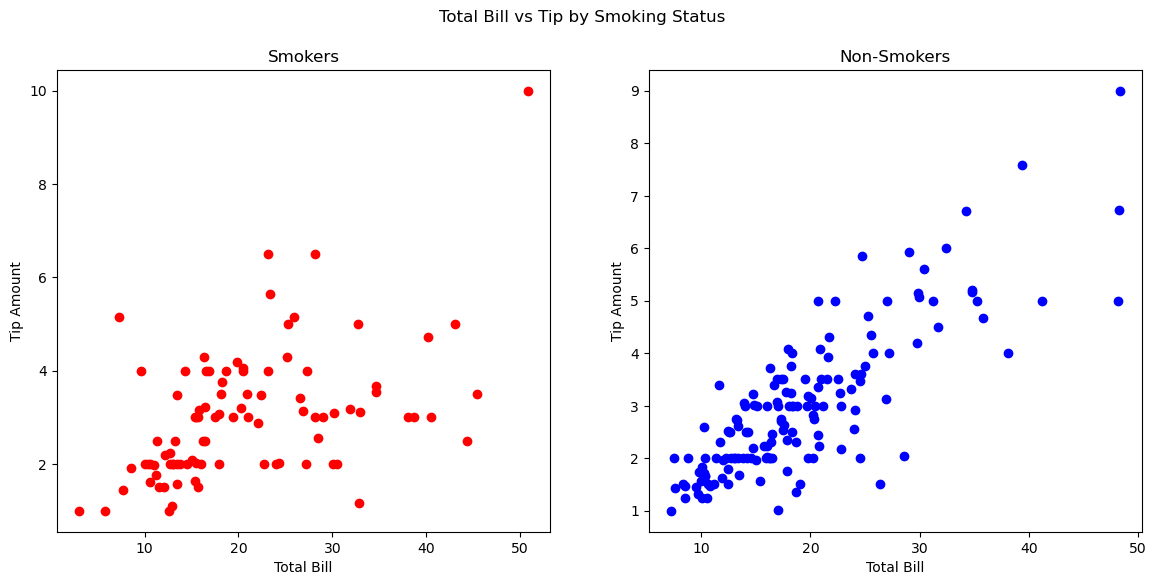

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(smokers['total_bill'], smokers['tip'], color='red')
axes[0].set_title('Smokers')
axes[0].set_xlabel('Total Bill')
axes[0].set_ylabel('Tip Amount')
axes[1].scatter(non_smokers['total_bill'], non_smokers['tip'], color='blue')
axes[1].set_title('Non-Smokers')
axes[1].set_xlabel('Total Bill')
axes[1].set_ylabel('Tip Amount')
plt.suptitle('Total Bill vs Tip by Smoking Status')
plt.show()

Seaborn provides a higher-level interface for creating attractive and informative statistical graphics. For example, we can create scatter plots distinguishing between different categories using the relplot function

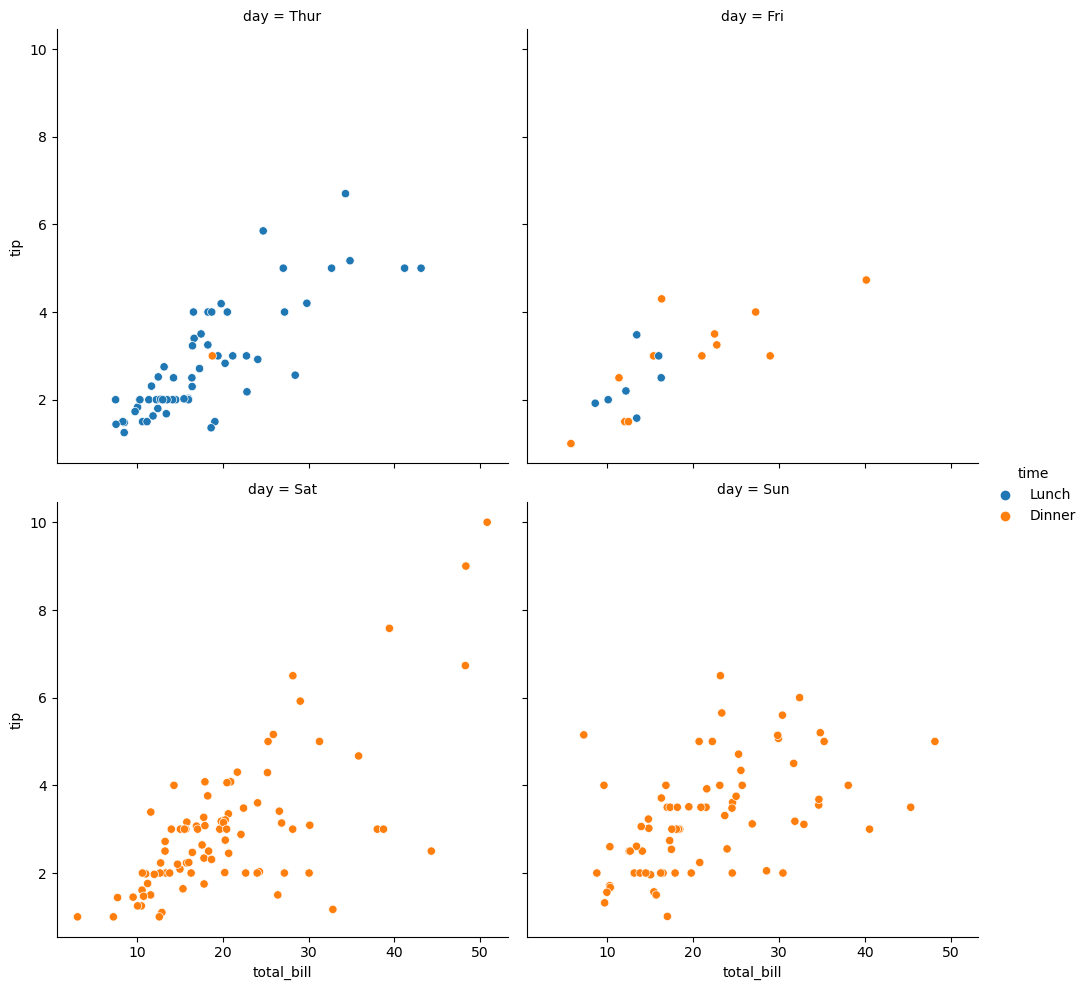

In [8]:
sns.relplot(data=df, x="total_bill", y="tip", hue="time", col="day", col_wrap=2)

where each subplot corresponds to a different day of the week, and points are colored based on whether the meal was lunch or dinner. We could have created the same plot using Matplotlib, but it would have required more code.

We can also create other types of plots using Seaborn, such as box plots to visualize the distribution of tips by day of the week

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


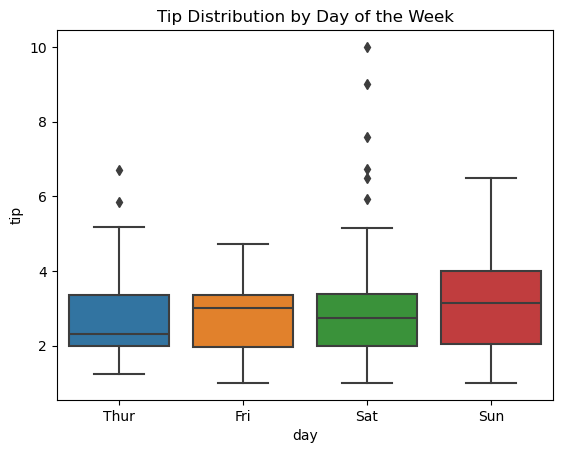

In [9]:
sns.boxplot(x='day', y='tip', data=df)
plt.title('Tip Distribution by Day of the Week')
plt.show()

As you can see, on Saturdays there are some very high tips compared to other days but the median tip on Fridays and Sundays still seems to be higher.

We can also create histograms to visualize the distribution of total bills

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


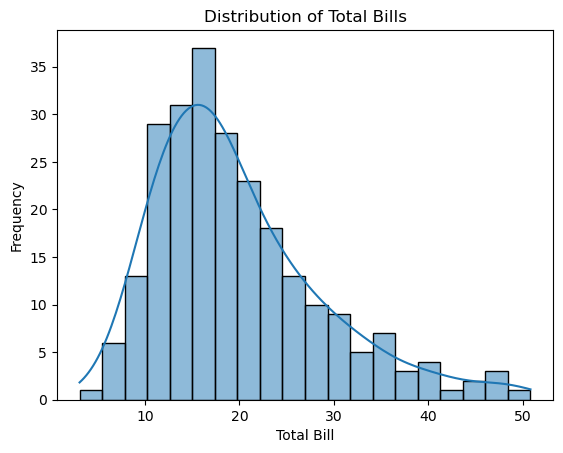

In [10]:
sns.histplot(df['total_bill'], bins=20, kde=True)
plt.title('Distribution of Total Bills')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

where the `kde=True` argument adds a kernel density estimate to the histogram, providing a smoothed curve that represents the distribution of total bills.

We can also create regression plots to visualize the relationship between total bill and tip amount

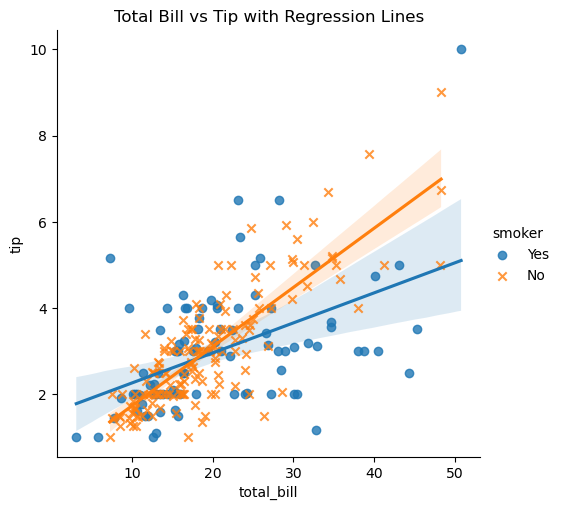

In [11]:
sns.lmplot(x='total_bill', y='tip', data=df, hue='smoker', markers=['o', 'x'])
plt.title('Total Bill vs Tip with Regression Lines')
plt.show()

which includes regression lines for smokers and non-smokers.

There are many more types of plots and customization options available in both Matplotlib and Seaborn. These libraries are powerful tools for data visualization in Python, and mastering them will greatly enhance your ability to communicate insights from data effectively. I recommend exploring their documentation and experimenting with different types of plots to become more familiar with their capabilities.